Import Library

In [72]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder


Load Data

In [73]:
df = pd.read_csv('data/gempa_1990-2019.csv')
print(df.shape)
df.head()


(50659, 22)


,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,...,updated,place,type,horizontalError,depthError,magError,magNst,status,locationSource,magSource
0,1994-12-30T21:28:48.450Z,-5.092,103.514,99.0,5.1,mb,NaN,NaN,NaN,1.0,...,2014-11-07T00:57:00.847Z,"121 km SSE of Pagar Alam, Indonesia",earthquake,NaN,21.7,NaN,19.0,reviewed,us,us
1,1994-12-30T03:46:35.310Z,-9.697,124.116,78.5,4.8,mb,NaN,NaN,NaN,1.3,...,2014-11-07T00:57:00.717Z,"25 km NW of Soe, Indonesia",earthquake,NaN,21.7,NaN,4.0,reviewed,us,us
2,1994-12-29T06:15:10.280Z,-8.608,119.387,142.2,4.2,mb,NaN,NaN,NaN,1.4,...,2014-11-07T00:57:00.590Z,"11 km W of Komodo, Indonesia",earthquake,NaN,15.8,NaN,2.0,reviewed,us,us
3,1994-12-29T04:33:53.090Z,-5.112,102.689,60.7,5.4,mb,NaN,NaN,NaN,0.9,...,2022-04-28T17:19:32.470Z,"135 km SSW of Pagar Alam, Indonesia",earthquake,NaN,11.7,NaN,30.0,reviewed,us,us
4,1994-12-28T22:39:23.700Z,5.211,126.316,72.5,5.0,mb,NaN,NaN,NaN,1.2,...,2014-11-07T00:57:00.531Z,"96 km ESE of Sarangani, Philippines",earthquake,NaN,15.6,NaN,6.0,reviewed,us,us


Eksplorasi Awal

In [74]:
print(df.dtypes)
print("\nJumlah nilai kosong:")
print(df.isnull().sum())


time                   str
latitude           float64
longitude          float64
depth              float64
mag                float64
magType                str
nst                float64
gap                float64
dmin               float64
rms                float64
net                    str
id                     str
updated                str
place                  str
type                   str
horizontalError    float64
depthError         float64
magError           float64
magNst             float64
status                 str
locationSource         str
magSource              str
dtype: object

Jumlah nilai kosong:
time                   0
latitude               0
longitude              0
depth                  0
mag                    0
magType                0
nst                25356
gap                15615
dmin               37251
rms                   36
net                    0
id                     0
updated                0
place                  0
type                

Preprocessing

In [75]:
df['time'] = pd.to_datetime(df['time'])
df['bulan'] = df['time'].dt.month
df['jam']   = df['time'].dt.hour

# Hanya pakai kolom yang datanya lengkap
fitur = ['latitude', 'longitude', 'depth', 'bulan', 'jam']
target = 'mag'

df_clean = df[fitur + [target]].dropna().reset_index(drop=True)

print(f"Data setelah cleaning: {df_clean.shape}")
df_clean.head()


Data setelah cleaning: (50659, 6)


,latitude,longitude,depth,bulan,jam,mag
0,-5.092,103.514,99.0,12,21,5.1
1,-9.697,124.116,78.5,12,3,4.8
2,-8.608,119.387,142.2,12,6,4.2
3,-5.112,102.689,60.7,12,4,5.4
4,5.211,126.316,72.5,12,22,5.0


In [76]:
print("Shape df:", df.shape)
print("Shape df_clean:", df_clean.shape)
print("\nNilai kosong per kolom:")
print(df[['latitude', 'longitude', 'depth', 'gap', 'dmin', 'rms', 'nst', 'bulan', 'jam', 'mag']].isnull().sum())


Shape df: (50659, 24)
Shape df_clean: (50659, 6)

Nilai kosong per kolom:
latitude         0
longitude        0
depth            0
gap          15615
dmin         37251
rms             36
nst          25356
bulan            0
jam              0
mag              0
dtype: int64


Buat Label Kelas

In [77]:
def buat_label(mag):
    if mag < 5.0:
        return 0  # Low-magnitude
    else:
        return 1  # High-magnitude

df_clean['label'] = df_clean['mag'].apply(buat_label)

label_nama = {0: 'Low-magnitude', 1: 'High-magnitude'}
print(df_clean['label'].value_counts().rename(label_nama))


label
Low-magnitude     43325
High-magnitude     7334
Name: count, dtype: int64


Split Data

In [78]:
X = df_clean[fitur]
y = df_clean['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")


Train: (40527, 5), Test: (10132, 5)


In [79]:
print(y_train.unique())
print(y_test.unique())


[0 1]
[0 1]


Training XGBoost

In [80]:
from sklearn.utils.class_weight import compute_sample_weight

sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    eval_metric='mlogloss',
    random_state=42
)

model.fit(X_train, y_train, sample_weight=sample_weights)


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

Evaluasi

In [81]:
y_pred = model.predict(X_test)
from sklearn.metrics import recall_score, f1_score

print("Akurasi:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=label_nama.values()))


print("Recall High-magnitude:", recall_score(y_test, y_pred, pos_label=1))
print("F1 High-magnitude:", f1_score(y_test, y_pred, pos_label=1))



Akurasi: 0.6688709040663245

Classification Report:
                precision    recall  f1-score   support

 Low-magnitude       0.89      0.70      0.78      8665
High-magnitude       0.22      0.50      0.31      1467

      accuracy                           0.67     10132
     macro avg       0.56      0.60      0.54     10132
  weighted avg       0.80      0.67      0.71     10132

Recall High-magnitude: 0.5044308111792775
F1 High-magnitude: 0.30610134436401243


Confusion Matrix

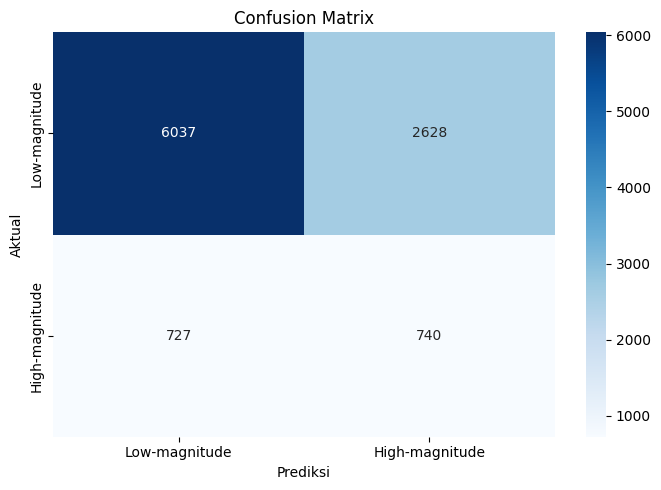

In [82]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_nama.values(),
            yticklabels=label_nama.values())
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()


Feature Importance

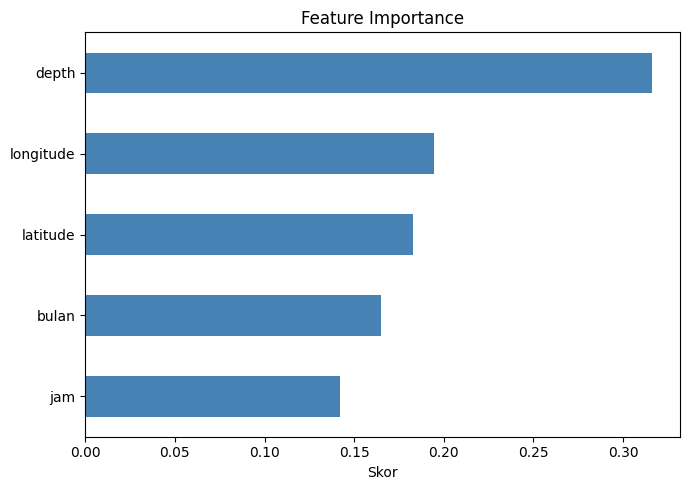

In [83]:
importance = pd.Series(model.feature_importances_, index=fitur).sort_values(ascending=True)

plt.figure(figsize=(7, 5))
importance.plot(kind='barh', color='steelblue')
plt.title('Feature Importance')
plt.xlabel('Skor')
plt.tight_layout()
plt.show()


Distribusi Magnitudo (Opsional, EDA)

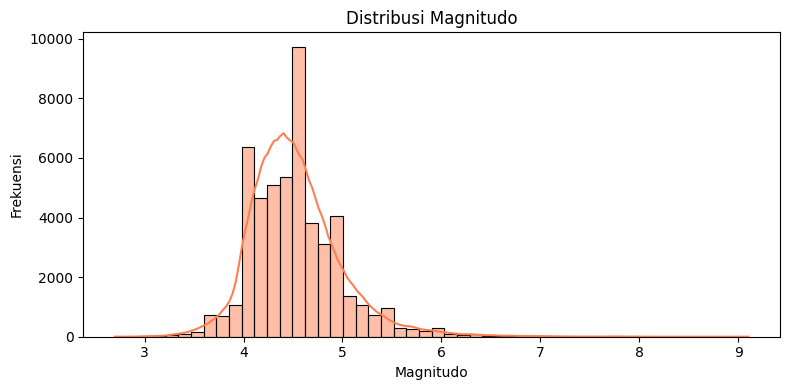

In [84]:
plt.figure(figsize=(8, 4))
sns.histplot(df_clean['mag'], bins=50, kde=True, color='coral')
plt.title('Distribusi Magnitudo')
plt.xlabel('Magnitudo')
plt.ylabel('Frekuensi')
plt.tight_layout()
plt.show()


Model yang sudah di training

In [85]:
import joblib
joblib.dump(model, 'model_gempa.pkl')


['model_gempa.pkl']

Pembuktian Data Training

In [86]:
LABEL = {0: 'Ringan', 1: 'Sedang', 2: 'Kuat', 3: 'Besar'}

sample = X_test.iloc[0]
print("Fitur:", sample.values)
print("Label asli:", LABEL[y_test.iloc[0]])
print("Prediksi model:", LABEL[model.predict([sample])[0]])


Fitur: [ -1.076 123.488  70.      7.     18.   ]
Label asli: Ringan
Prediksi model: Ringan
